## Name : M Danish Zaheer
## Roll No : 25280092

# Task-2

##### Note: I have taken this code file from PA2 to download trained model trained in that PA, as suggested that we can use pretrained model from that PA, otheriwse I would have only taken raw data and done all preprocessing from scratch and divide data into train val test split and only use train data for imputations and all mean median and mode calculations then same imputes need to be done in val and test also create a derived features plus define a preprocessor pipeline accordingly  

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)
import joblib

np.random.seed(42)
print("All imports successful.")

All imports successful.


In [2]:
# 1. Load CSV
df = pd.read_csv(Path("..")/"Data/PakWheelsData.csv")

# 2. Drop addref
df = df.drop(columns=["addref"])

# 3. Drop assembly
# counting NAN as a unique as well by putting constraint of dropna=False otherwise 1 unique if True
print("Unique values in assembly column:", df["assembly"].nunique(dropna=False))
print("\n")
print("Nan vs filled values in assembly column:")
print(df["assembly"].value_counts(dropna=False))
df = df.drop(columns=["assembly"])

# 4. Shape and head
print("\n")
print("Shape:", df.shape)
df.head()

Unique values in assembly column: 2


Nan vs filled values in assembly column:
assembly
NaN         42928
Imported    19374
Name: count, dtype: int64


Shape: (62302, 12)


,city,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,Islamabad,Compact SUV,KIA,Sorento,2021.0,3500.0,Automatic,Petrol,NaN,Islamabad,54654,9300000.0
1,Sadiqabad,Hatchback,Daihatsu,Mira,2020.0,660.0,Automatic,Petrol,White,Punjab,10000,3700000.0
2,Peshawar,Hatchback,Toyota,Vitz,2018.0,1000.0,Automatic,Petrol,Silver,Islamabad,123000,4150000.0
3,Lahore,Sedan,Toyota,Corolla,2019.0,1600.0,Automatic,Petrol,White,Lahore,105000,4850000.0
4,Islamabad,Sedan,Toyota,Corolla,2022.0,1600.0,Automatic,Petrol,White,Islamabad,6500,6600000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62302 entries, 0 to 62301
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          62302 non-null  object 
 1   body          55211 non-null  object 
 2   make          62302 non-null  object 
 3   model         62302 non-null  object 
 4   year          58516 non-null  float64
 5   engine        62299 non-null  float64
 6   transmission  62302 non-null  object 
 7   fuel          61593 non-null  object 
 8   color         61110 non-null  object 
 9   registered    62302 non-null  object 
 10  mileage       62302 non-null  int64  
 11  price         61830 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 5.7+ MB


In [4]:
df.describe()

,year,engine,mileage,price
count,58516.000000,62299.000000,62302.000000,6.183000e+04
mean,2012.843991,1406.731887,91043.031476,3.886141e+06
std,7.497370,706.209678,89279.502257,5.452661e+06
min,1990.000000,3.000000,1.000000,1.100000e+05
25%,2007.000000,1000.000000,34000.000000,1.450000e+06
50%,2015.000000,1300.000000,80000.000000,2.700000e+06
75%,2019.000000,1600.000000,123456.000000,4.500000e+06
max,2022.000000,15000.000000,1000000.000000,1.650000e+08


In [5]:
# 1. Missing value summary DataFrame
values = df.isnull().sum() 
count = values
percent = (values/len(df))*100
summary = pd.DataFrame()
summary["missing values count"] = count
summary["missing values percentage"] = percent
summary = summary[summary["missing values count"] > 0]
summary = summary.sort_values(by="missing values percentage", ascending=False)
print("Summary of missing values :")
display(summary)

Summary of missing values :


,missing values count,missing values percentage
body,7091,11.381657
year,3786,6.076851
color,1192,1.913261
fuel,709,1.138005
price,472,0.757600
engine,3,0.004815


In [6]:
# Donot modify this
numerical_columns = ["year", "engine", "mileage", "price"]

print("Summary of numerical:")
display(df[numerical_columns].describe())

Summary of numerical:


,year,engine,mileage,price
count,58516.000000,62299.000000,62302.000000,6.183000e+04
mean,2012.843991,1406.731887,91043.031476,3.886141e+06
std,7.497370,706.209678,89279.502257,5.452661e+06
min,1990.000000,3.000000,1.000000,1.100000e+05
25%,2007.000000,1000.000000,34000.000000,1.450000e+06
50%,2015.000000,1300.000000,80000.000000,2.700000e+06
75%,2019.000000,1600.000000,123456.000000,4.500000e+06
max,2022.000000,15000.000000,1000000.000000,1.650000e+08


In [7]:
#
df_cleaned = df.copy()
before = len(df_cleaned)

df_cleaned = df_cleaned[
    (df_cleaned["price"]   >= 500_000)    &
    (df_cleaned["price"]   <= 30_000_000) &
    (df_cleaned["mileage"] >= 100)        &
    (df_cleaned["mileage"] <= 500_000)    &
    (df_cleaned["engine"]  >= 100)        &
    (df_cleaned["year"]    >= 1990)
]

print(f"Rows removed: {before - len(df_cleaned):,} | Remaining: {len(df_cleaned):,}")

Rows removed: 6,931 | Remaining: 55,371


In [8]:
# Handle all remaining missing values on df_cleaned.
# Use the strategy you justified in Part 4.
# Remember: rows where 'price' is missing cannot be labelled — they must be dropped.

# NOTE: removing outliers results in missing values with only 3 columns so I will be hndlingling only
# those although the strategy discussed in part-4 is the general case strategy 
# tuturial helped: https://www.youtube.com/watch?v=VRmXto2YA2I
# I have debugged this code of groupby part using AI, I acknowledged that but first try is made by myself using tutorial

df_cleaned_2 = df_cleaned.dropna(subset=["body"])
# the lambda function is taking most frequent value after make model body pair and filling body value with it
group_mode = df_cleaned_2.groupby(["make", "model"])["body"].agg(lambda x: x.mode().iloc[0]) 
missing_rows_entries = df_cleaned["body"].isna()

for i in df_cleaned[missing_rows_entries].index:
    make = df_cleaned.loc[i, "make"]
    model = df_cleaned.loc[i, "model"]
    if (make, model) in group_mode.index:
        df_cleaned.loc[i, "body"] = group_mode[(make, model)]

# dropping rows from body after imputation with groupby mode(100% matching values imputed only) the missing%(0.4%) is quite low after that 
# dropping fuel because the missing count is quite low after handling outliers only 0.6%
# filling missing values with unknown in color still closer 2%
df_cleaned = df_cleaned.dropna(subset=["body"])
df_cleaned = df_cleaned.dropna(subset=["fuel"])
df_cleaned["color"] = df_cleaned["color"].fillna("Unknown")

# DO NOT REMOVE — must pass before continuing
assert df_cleaned.isnull().sum().sum() == 0, "Still has missing values!"
print("Shape after cleaning:", df_cleaned.shape)
print("No missing values remain ✓")

Shape after cleaning: (54791, 12)
No missing values remain ✓


In [9]:
#
median_price = df_cleaned["price"].median()
print(f"Median price: {median_price:,.0f} PKR")


Median price: 2,800,000 PKR


Value count wise:
HighPrice
1    27425
0    27366
Name: count, dtype: int64


Percentage wise:
HighPrice
1    0.500538
0    0.499462
Name: count, dtype: float64


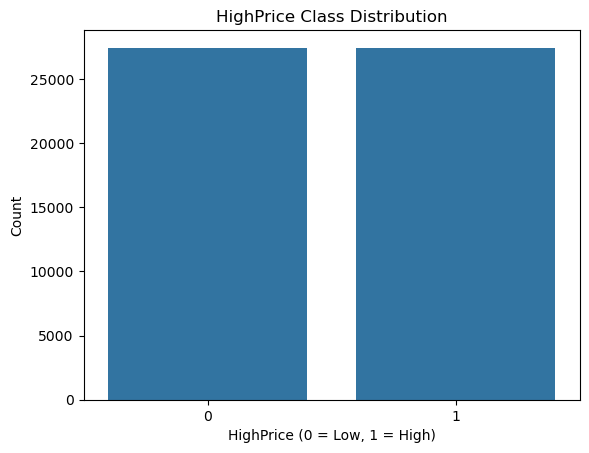

In [10]:
# 1. Create df_cleaned["HighPrice"]  (1 if price >= median_price, else 0)
df_cleaned["HighPrice"] = (df_cleaned["price"] >= median_price).astype(int)

# 2. Drop the original 'price' column from df_cleaned
df_cleaned = df_cleaned.drop(columns=["price"])

# 3. Print class counts and proportions
count_1 = df_cleaned["HighPrice"].value_counts()
count_2 = df_cleaned["HighPrice"].value_counts()/len(df_cleaned)

print("Value count wise:")
print(count_1)
print("\n")
print("Percentage wise:")
print(count_2)

# 4. Plot class distribution (countplot)
sns.countplot(x="HighPrice", data=df_cleaned)
plt.title("HighPrice Class Distribution")
plt.xlabel("HighPrice (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

In [11]:
# Build X and y
X = df_cleaned.drop(columns=["HighPrice"])
y = df_cleaned["HighPrice"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, stratify=y)

# Print shapes and class proportions in y_train
print("Xtrain shape:", X_train.shape)
print("Xtest shape :", X_test.shape)
print("ytrain shape:", y_train.shape)
print("ytest shape :", y_test.shape)
print("\n")
print("Class proportions in ytrain:")
print(y_train.value_counts()/len(y_train))

Xtrain shape:

 (38353, 11)
Xtest shape : (16438, 11)
ytrain shape: (38353,)
ytest shape : (16438,)


Class proportions in ytrain:
HighPrice
1    0.500535
0    0.499465
Name: count, dtype: float64


In [12]:
# Do not modify this
max_year_train = X_train["year"].max()
print(f"max_year_train = {max_year_train}  (from X_train only)")

X_train = X_train.copy()
X_test  = X_test.copy()

max_year_train = 2022.0  (from X_train only)


In [13]:
# car_age and mileage_per_year on X_train
X_train["car_age"] = max_year_train - X_train["year"]
X_train["mileage_per_year"] = X_train["mileage"] / (X_train["car_age"] + 1)

# Same on X_test (use max_year_train — do NOT recompute from X_test)
X_test["car_age"] = max_year_train - X_test["year"]
X_test["mileage_per_year"] = X_test["mileage"] / (X_test["car_age"] + 1)

# Verify
print(X_train[["year", "mileage", "car_age", "mileage_per_year"]].head(3))

         year  mileage  car_age  mileage_per_year
51981  2022.0    11000      0.0      11000.000000
718    2007.0   125000     15.0       7812.500000
30894  2012.0   200000     10.0      18181.818182


In [14]:
# YOUR CODE HERE — Step 1: inspect columns
print(list(X_train.columns))
print(X_train.dtypes)

['city', 'body', 'make', 'model', 'year', 'engine', 'transmission', 'fuel', 'color', 'registered', 'mileage', 'car_age', 'mileage_per_year']
city                 object
body                 object
make                 object
model                object
year                float64
engine              float64
transmission         object
fuel                 object
color                object
registered           object
mileage               int64
car_age             float64
mileage_per_year    float64
dtype: object


In [15]:
# Define column groups
numerical_cols   = ["year", "engine", "mileage", "car_age", "mileage_per_year"]   # fill in
categorical_cols = ["city", "body", "make", "model", "transmission", "fuel", "color", "registered"]  # fill in

# Numerical sub-pipeline
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical sub-pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessor built.")
preprocessor

Preprocessor built.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [16]:
svm_linear = SVC(kernel="linear", probability=True)

pipeline_linear = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", svm_linear)
])

pipeline_linear.fit(X_train, y_train)                        # fit

y_pred_linear  = pipeline_linear.predict(X_test)             # predict labels
y_score_linear = pipeline_linear.predict_proba(X_test)[:, 1] # predict_proba(X_test)[:, 1]

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy: {acc_linear:.4f}")

Linear SVM Accuracy: 0.9496


In [17]:
svm_rbf = SVC(kernel="rbf", probability=True)

pipeline_rbf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", svm_rbf)
])

pipeline_rbf.fit(X_train, y_train)                     # fit

y_pred_rbf  = pipeline_rbf.predict(X_test)             # predict labels
y_score_rbf = pipeline_rbf.predict_proba(X_test)[:, 1] # predict_proba(X_test)[:, 1]

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM Accuracy: {acc_rbf:.4f}")

RBF SVM Accuracy: 0.9552


In [18]:
# YOUR CODE HERE — Task 1: reports
print(f"Linear SVM: {acc_linear:.4f}  |  RBF SVM: {acc_rbf:.4f}\n")

# report for both
print("Report for Linear SVM")
print(classification_report(y_test, y_pred_linear))
print("Report for RBF SVM")
print(classification_report(y_test, y_pred_rbf))

Linear SVM: 0.9496  |  RBF SVM: 0.9552

Report for Linear SVM
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      8210
           1       0.95      0.95      0.95      8228

    accuracy                           0.95     16438
   macro avg       0.95      0.95      0.95     16438
weighted avg       0.95      0.95      0.95     16438

Report for RBF SVM
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      8210
           1       0.95      0.96      0.96      8228

    accuracy                           0.96     16438
   macro avg       0.96      0.96      0.96     16438
weighted avg       0.96      0.96      0.96     16438



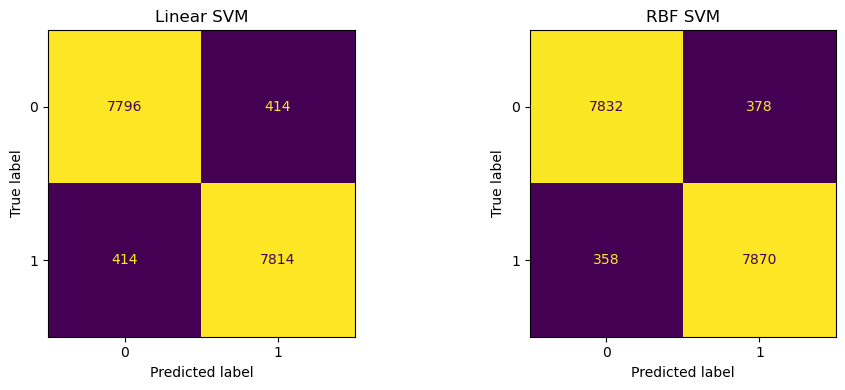

In [19]:
# YOUR CODE HERE — Task 2: confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_linear = confusion_matrix(y_test, y_pred_linear)
# plot on axes[0]
ConfusionMatrixDisplay(confusion_matrix=cm_linear).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Linear SVM")

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
# plot on axes[1]
ConfusionMatrixDisplay(confusion_matrix=cm_rbf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("RBF SVM")

plt.tight_layout(); plt.show()

In [20]:
rfe_estimator = LinearSVC(max_iter=5000, random_state=42)

pipeline_rfe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("selector",   RFE(estimator=rfe_estimator, n_features_to_select=30, step=50)),
    ("svm",        SVC(kernel="linear", probability=True, random_state=42))         # SVC(kernel="linear", probability=True, random_state=42)
])

pipeline_rfe.fit(X_train, y_train)                                                  # fit
rfe_ypred = pipeline_rfe.predict(X_test)                                            # predict
acc_rfe = accuracy_score(y_test, rfe_ypred)
print(f"RFE Accuracy: {acc_rfe:.4f}")

feature_names = preprocessor.get_feature_names_out()
support       = pipeline_rfe.named_steps["selector"].support_
selected      = feature_names[support]
print(f"\nSelected {len(selected)} features:")
for f in selected: print(" ", f)

RFE Accuracy: 0.7259

Selected 30 features:
  cat__city_Murree
  cat__make_Changan
  cat__make_FAW
  cat__make_Prince
  cat__make_Subaru
  cat__make_Suzuki
  cat__make_United
  cat__model_Acty
  cat__model_Alsvin
  cat__model_Belta
  cat__model_Cami
  cat__model_Carol
  cat__model_Celerio
  cat__model_Ciaz
  cat__model_Gen
  cat__model_Kizashi
  cat__model_Life
  cat__model_Minica
  cat__model_Mirage
  cat__model_Note
  cat__model_Porte
  cat__model_Probox
  cat__model_Ractis
  cat__model_Santro
  cat__model_Toppo
  cat__model_Town
  cat__model_Vamos
  cat__model_Zest
  cat__color_Pearl White Metallic
  cat__color_White 


In [21]:
joblib.dump(pipeline_rbf, "pakwheels_svm_model.pkl")

['pakwheels_svm_model.pkl']